# Project 2: Nearest Neighbor Search

In this project, we step up the difficulty! We will simulate a scenario where we have the coordinates of 1000 stores and a single user. We need to find the 5 stores that are closest to the user.

**Algorithm Context:** What we are building here is the core engine behind the famous **K-Nearest Neighbors (KNN)** machine learning algorithm, using the **Euclidean Distance** metric!

This project will heavily test your understanding of:
1. Multi-dimensional Arrays
2. Broadcasting
3. Mathematical Operations (Euclidean Distance)
4. Sorting Arrays (`np.argsort`)
5. Boolean Indexing

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(101)

# Generate 1000 store locations (X, Y coordinates between 0 and 100)
store_locations = np.random.uniform(low=0, high=100, size=(1000, 2))

# Generate 1 user location
user_location = np.array([50, 50])

print("First 5 store locations:\n", store_locations[:5])
print("\nUser location:", user_location)

First 5 store locations:
 [[51.63986277 57.06675869]
 [ 2.84742265 17.15216562]
 [68.52769817 83.38968626]
 [30.69662197 89.36130797]
 [72.15438618 18.99389542]]

User location: [50 50]


## 1. Calculating Euclidean Distance
The Euclidean distance between two points $(x_1, y_1)$ and $(x_2, y_2)$ is $\sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$.
Using NumPy broadcasting, we can calculate the distance from the `user_location` to **all** 1000 `store_locations` simultaneously!

In [2]:
# Calculate the differences in X and Y coordinates
# Broadcasting happens here: (1000, 2) - (2,)
differences = store_locations - user_location

# Square the differences
squared_differences = differences ** 2

# Sum along the X and Y axis (axis=1) to get the sum of squared differences for each store
sum_squared_differences = np.sum(squared_differences, axis=1)

# Take the square root to get the final Euclidean distances
distances = np.sqrt(sum_squared_differences)

# Alternatively, in a single elegant line:
# distances = np.linalg.norm(store_locations - user_location, axis=1)

print("Distances to the first 5 stores:", distances[:5])

Distances to the first 5 stores: [ 7.25453157 57.46604018 38.18568774 43.83985594 38.10768096]


## 2. Finding the Closest Stores
Now that we have an array of 1000 distances, we need to find which stores have the *smallest* distances.

In [3]:
# Use np.argsort() to get the indices that would sort the distances array
sorted_indices = np.argsort(distances)

# Get the indices of the 5 closest stores
closest_5_indices = sorted_indices[:5]

# Use fancy indexing to get the coordinates of these 5 stores
closest_5_stores = store_locations[closest_5_indices]
closest_5_distances = distances[closest_5_indices]

print("Indices of 5 closest stores:", closest_5_indices)
print("\nDistances to the 5 closest stores:\n", closest_5_distances)
print("\nCoordinates of the 5 closest stores:\n", closest_5_stores)

Indices of 5 closest stores: [830 796 797 188 856]

Distances to the 5 closest stores:
 [2.45099084 3.43667437 4.01394873 4.02489744 4.09738705]

Coordinates of the 5 closest stores:
 [[52.21220062 48.94476329]
 [53.4351679  50.10174587]
 [53.6765784  51.61076246]
 [51.93187694 53.53095608]
 [47.92400099 46.46746426]]


## 3. Conditional Searching (Stores within a Radius)
What if we want to find *all* stores that are within a 10km radius (distance < 10)?

In [4]:
# Create a boolean mask for distances less than 10
within_radius_mask = distances < 10

# Count how many stores are within the radius
num_stores_within_radius = np.count_nonzero(within_radius_mask)

# Get their coordinates
stores_within_radius = store_locations[within_radius_mask]

print(f"There are {num_stores_within_radius} stores within a 10 unit radius.")
print("Their coordinates are:\n", stores_within_radius)

There are 33 stores within a 10 unit radius.
Their coordinates are:
 [[51.63986277 57.06675869]
 [52.06653967 57.87895355]
 [52.09261941 46.23825656]
 [47.9562792  44.32314563]
 [43.4099808  47.20916126]
 [51.93187694 53.53095608]
 [49.8773927  40.19716759]
 [42.84046075 44.46581405]
 [48.07772246 58.16307142]
 [50.63731128 56.03596771]
 [47.44989578 56.27521449]
 [44.37426655 48.20014267]
 [47.91231983 41.84637065]
 [53.00718936 46.52161819]
 [56.27513782 56.93617985]
 [44.76151219 52.0300967 ]
 [43.49647736 54.53526646]
 [53.01404943 57.55242483]
 [55.96873329 48.98078361]
 [55.67441696 45.23730108]
 [43.71950597 46.39624296]
 [54.96238708 50.17812741]
 [46.55935259 57.03195488]
 [45.46537578 50.12533645]
 [56.24839725 48.43891283]
 [44.35347663 42.23142446]
 [42.52434298 54.09493927]
 [42.09182429 54.04752087]
 [53.4351679  50.10174587]
 [53.6765784  51.61076246]
 [53.01763205 58.34314628]
 [52.21220062 48.94476329]
 [47.92400099 46.46746426]]


## 4. Visualization
Let's visualize our user, all the stores, and highlight the 5 closest ones!

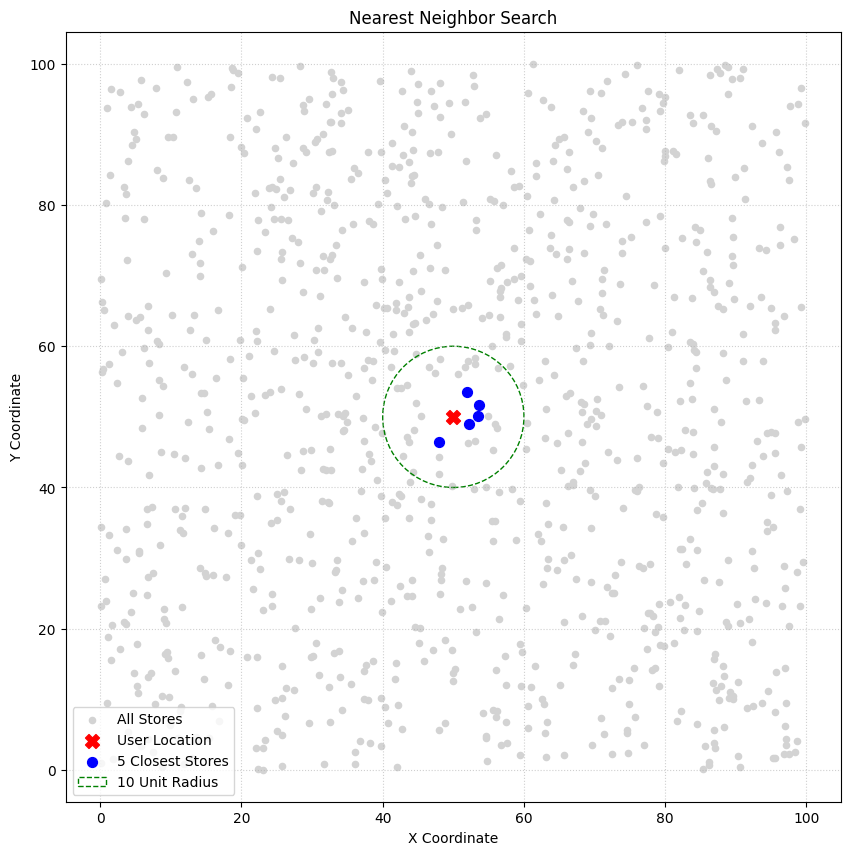

In [5]:
plt.figure(figsize=(10, 10))

# Plot all stores in light gray
plt.scatter(store_locations[:, 0], store_locations[:, 1], color='lightgray', s=20, label='All Stores')

# Plot the user in red
plt.scatter(user_location[0], user_location[1], color='red', s=100, marker='X', label='User Location')

# Highlight the 5 closest stores in blue
plt.scatter(closest_5_stores[:, 0], closest_5_stores[:, 1], color='blue', s=50, label='5 Closest Stores')

# Draw a circle for the 10-unit radius
circle = plt.Circle((user_location[0], user_location[1]), 10, color='green', fill=False, linestyle='--', label='10 Unit Radius')
plt.gca().add_patch(circle)

plt.title("Nearest Neighbor Search")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Ensure circle looks like a circle
plt.show()